# Ride Bookings — EDA
**Steps:** Load → Clean → Select Columns → Analyze → Visualize

In [22]:
import os

# ── Output directory for saved plots ──────────────────────────────────
SAVE_DIR = r"C:\Users\Muhammad Waqas"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Charts will be saved to: {os.path.abspath(SAVE_DIR)}')

Charts will be saved to: C:\Users\Muhammad Waqas


## Step 1 — Import Libraries


We load the core data-science stack:
- **pandas / numpy** — data wrangling and numeric operations
- **matplotlib / seaborn** — static visualisations
- **warnings** suppressed so output stays clean
- `plt.rcParams` sets a default figure size so every chart is consistently sized
- `sns.set_theme(style='whitegrid')` keeps charts readable with subtle grid lines

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('Libraries loaded ✅')

Libraries loaded ✅


## Step 2 — Load Data


We read the raw CSV into a DataFrame and immediately check its shape.
- **What to look for:** row count × column count gives an instant sense of dataset size.
- A large row count (>50 k) means aggregation will be important; a high column count (>20) signals potential redundancy that the next steps will address.

In [24]:
# UPDATE this path if needed

df_raw = pd.read_csv(r'E:\DATA IS FUTURE\Python\Rider\rideBookings.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (150000, 21)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


## Step 3 — Initial Inspection


Three quick diagnostics before touching a single value:
1. **dtypes** — confirms numeric vs. object columns and flags columns pandas auto-parsed incorrectly (e.g., dates stored as `object`).
2. **Null counts** — raw counts show which columns have gaps.
3. **Null %** — percentage is more actionable: a 5 % gap can be imputed; a 90 % gap usually means the column should be dropped.

In [25]:
print('=== Data Types ===')
print(df_raw.dtypes)
print('\n=== Null Counts ===')
print(df_raw.isnull().sum())
print('\n=== Null % ===')
print((df_raw.isnull().mean() * 100).round(1))

=== Data Types ===
Date                                     str
Time                                     str
Booking ID                               str
Booking Status                           str
Customer ID                              str
Vehicle Type                             str
Pickup Location                          str
Drop Location                            str
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer        str
Cancelled Rides by Driver            float64
Driver Cancellation Reason               str
Incomplete Rides                     float64
Incomplete Rides Reason                  str
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                           str
dtype: object

=== Null Counts ===
D

## Step 4 — Drop Redundant / High-Null Columns

**Dropped columns & reasoning:**
- `Cancelled Rides by Customer` / `Reason for cancelling by Customer` — 93% null (only relevant for ~7% of rides)
- `Cancelled Rides by Driver` / `Driver Cancellation Reason` — 82% null
- `Incomplete Rides` / `Incomplete Rides Reason` — 94% null
- `Avg CTAT` — 32% null, high redundancy with VTAT

**Kept columns:** core booking info, timing, locations, value, distance, ratings, payment.

### Step 4: Drop Redundant / High-Null Columns
**Principle:** columns with >80 % null values carry almost no signal for population-level analysis and inflate memory usage.
- Cancellation and incomplete-ride columns are relevant only for the tiny fraction of rides they describe; they can be revisited in a targeted sub-analysis.
- Dropping `Avg CTAT` (32 % null, correlated with VTAT) reduces multicollinearity in any downstream modelling.
- **Output to verify:** the retained column list should contain booking ID, datetime, locations, vehicle type, value, distance, ratings, and payment method.

In [26]:
COLS_TO_DROP = [
    'Cancelled Rides by Customer',
    'Reason for cancelling by Customer',
    'Cancelled Rides by Driver',
    'Driver Cancellation Reason',
    'Incomplete Rides',
    'Incomplete Rides Reason',
    'Avg CTAT',
]

df = df_raw.drop(columns=COLS_TO_DROP)
print(f'Columns kept: {df.shape[1]}  |  Dropped: {len(COLS_TO_DROP)}')
print(df.columns.tolist())

Columns kept: 14  |  Dropped: 7
['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']


## Step 5 — Clean & Fix Data Types


Data-type correctness unlocks almost every downstream analysis:
- **DateTime parsing** enables temporal breakdowns (hour, day-of-week, month trends).
- **Stripping whitespace** from string columns prevents silent duplicates (e.g., `"UPI "` ≠ `"UPI"`).
- **Deduplication on Booking ID** ensures each transaction is counted once — essential for value aggregations.
- **Negative-value guard** on numeric columns (value, distance, ratings) replaces nonsensical entries with `NaN` so they're excluded from statistics rather than distorting them.

In [27]:
# Parse datetime
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df['Date']     = pd.to_datetime(df['Date'], errors='coerce')
df['Hour']     = df['DateTime'].dt.hour
df['Month']    = df['DateTime'].dt.month
df['DayOfWeek']= df['DateTime'].dt.day_name()

# Rename for clarity
df.rename(columns={'Avg VTAT': 'Avg_VTAT_min'}, inplace=True)

# Strip whitespace from string columns
str_cols = df.select_dtypes('object').columns
df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())

# Remove duplicate Booking IDs
before = len(df)
df.drop_duplicates(subset='Booking ID', inplace=True)
print(f'Duplicates removed: {before - len(df)}')

# Sanity check: negative values
for col in ['Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']:
    neg = (df[col] < 0).sum()
    if neg: print(f'  ⚠ {col}: {neg} negative values → set to NaN')
    df.loc[df[col] < 0, col] = np.nan

print(f'\nClean shape: {df.shape}')
df.head()

Duplicates removed: 1233

Clean shape: (148767, 18)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg_VTAT_min,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,DateTime,Hour,Month,DayOfWeek
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,3,Saturday
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,11,Friday
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,8,Friday
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,10,Monday
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,9,Monday


## Step 6 — Summary Statistics


`describe(include='all')` gives a single-table snapshot of every column:
- **Numeric columns:** check mean vs. median (large gap → skew/outliers), min/max for plausibility, std for spread.
- **Object columns:** `unique` and `top` reveal cardinality and the dominant category.
- **Key questions to answer here:** Is `Booking Value` heavily right-skewed? Are ratings clustered near the top (ceiling effect)? How many distinct vehicle types and payment methods exist?

In [28]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,148767,NaN,NaN,NaN,2024-06-30 17:31:29.475488,2024-01-01 00:00:00,2024-04-01 00:00:00,2024-07-01 00:00:00,2024-09-30 00:00:00,2024-12-30 00:00:00,NaN
Time,148767,62705,17:44:57,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking ID,148767,148767,"""CNR5884300""",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking Status,148767,5,Completed,92248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,148767,147580,"""CID6468528""",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Type,148767,7,Auto,37129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pickup Location,148767,176,Khandsa,947,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Drop Location,148767,176,Ashram,930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avg_VTAT_min,138366.0,NaN,NaN,NaN,8.454819,2.0,5.3,8.3,11.3,20.0,3.773341
Booking Value,101175.0,NaN,NaN,NaN,508.29023,50.0,234.0,414.0,689.0,4277.0,395.913208


## Step 7 — Booking Status Distribution


Understanding the split between completed, cancelled, and incomplete rides is the **single most important business metric** in a ride-hailing dataset.
- A **bar chart** makes count differences easy to read; annotation shows exact numbers.
- A **pie chart** communicates proportions at a glance.
- **Insight to watch for:** if cancellations exceed 20–25 % of bookings, that signals a driver-supply or pricing problem worth deep-diving.

Saved → C:\Users\Muhammad Waqas/plot_01.png


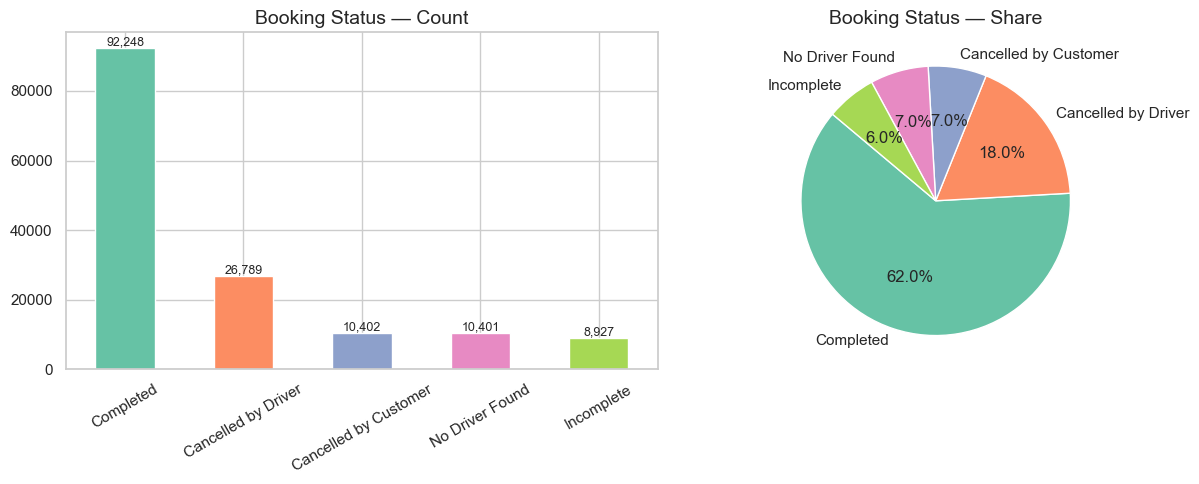

In [29]:
status_counts = df['Booking Status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
status_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(status_counts)))
axes[0].set_title('Booking Status — Count', fontsize=14)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(status_counts)), startangle=140)
axes[1].set_title('Booking Status — Share', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'plot_01.png'), dpi=150, bbox_inches='tight')
print(f'Saved → {SAVE_DIR}/plot_01.png')
plt.show()

## Step 8 — Vehicle Type Analysis


Two sub-questions answered side-by-side:
1. **Volume** — which vehicle type is most in demand? Supply allocation should match.
2. **Average value** — which type generates the most revenue per ride? A high-volume but low-value type may be less profitable than a niche premium type.
- **Insight to watch for:** a large gap between volume rank and value rank suggests pricing misalignment or demand for premium vehicles that isn't being captured.

Saved → C:\Users\Muhammad Waqas/plot_02.png


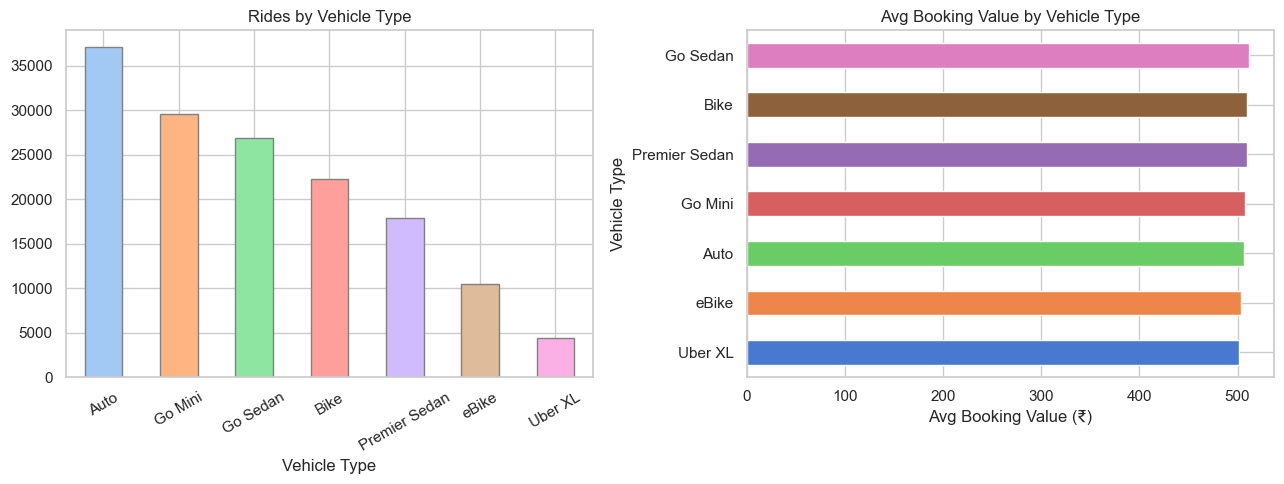

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df['Vehicle Type'].value_counts().plot(kind='bar', ax=axes[0],
    color=sns.color_palette('pastel'), edgecolor='grey')
axes[0].set_title('Rides by Vehicle Type')
axes[0].tick_params(axis='x', rotation=30)

df.groupby('Vehicle Type')['Booking Value'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color=sns.color_palette('muted'))
axes[1].set_title('Avg Booking Value by Vehicle Type')
axes[1].set_xlabel('Avg Booking Value (₹)')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'plot_02.png'), dpi=150, bbox_inches='tight')
print(f'Saved → {SAVE_DIR}/plot_02.png')
plt.show()

## Step 9 — Ride Value & Distance Distributions


Histograms reveal the **shape** of continuous variables — something summary statistics alone cannot show.
- **Right skew** in `Booking Value` is expected (most rides are short/cheap; a few long rides inflate the mean).
- **Bimodal distance distribution** might indicate two distinct use-cases (city hops vs. airport transfers).
- **Outliers:** a very long tail may represent data-entry errors or genuine premium rides — worth flagging for business stakeholders.

Saved → C:\Users\Muhammad Waqas/plot_03.png


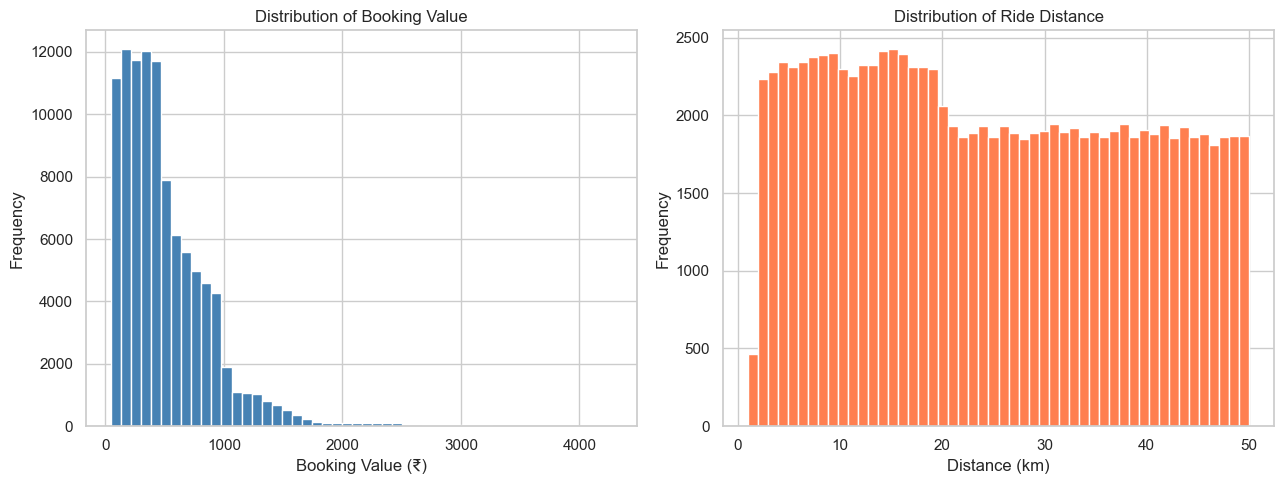

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df['Booking Value'].dropna().plot(kind='hist', bins=50, ax=axes[0],
    color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Booking Value')
axes[0].set_xlabel('Booking Value (₹)')

df['Ride Distance'].dropna().plot(kind='hist', bins=50, ax=axes[1],
    color='coral', edgecolor='white')
axes[1].set_title('Distribution of Ride Distance')
axes[1].set_xlabel('Distance (km)')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'plot_03.png'), dpi=150, bbox_inches='tight')
print(f'Saved → {SAVE_DIR}/plot_03.png')
plt.show()

## Step 10 — Ratings Analysis


Ratings in ride-hailing apps are notoriously **left-skewed** (most users rate 4–5; poor rides are under-reported).
- Compare **driver ratings vs. customer ratings** to see who tends to rate more harshly.
- A large difference between the two averages may indicate a bias in rating culture or a specific group (drivers or customers) that is dissatisfied.
- **Ceiling effect:** if >80 % of ratings are 5-star, the variable has little discriminative power for analysis.

Saved → C:\Users\Muhammad Waqas/plot_04.png


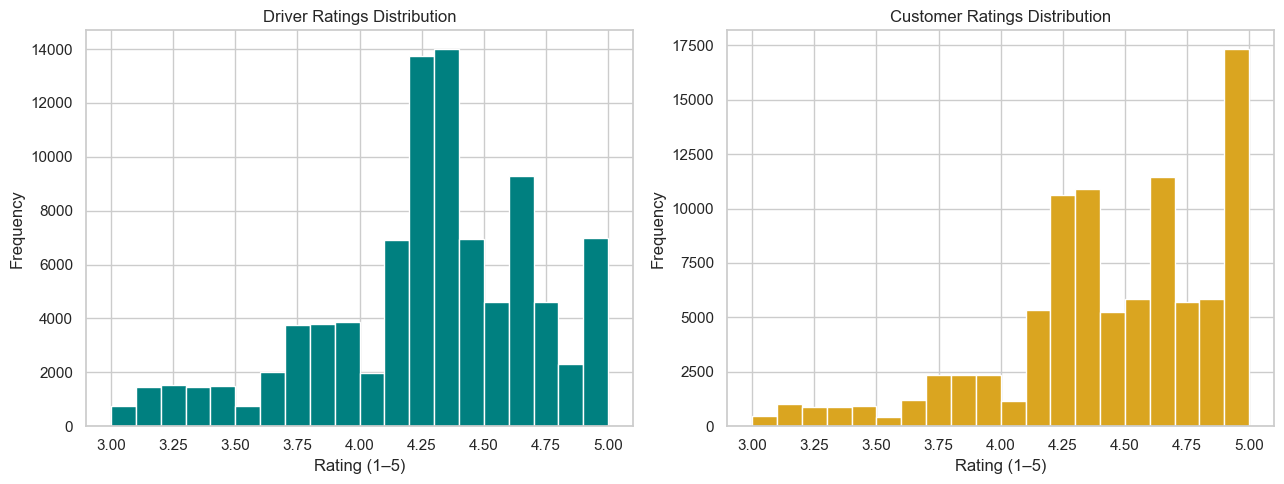

Mean Driver Rating   : 4.23
Mean Customer Rating : 4.40


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df['Driver Ratings'].dropna().plot(kind='hist', bins=20, ax=axes[0],
    color='teal', edgecolor='white')
axes[0].set_title('Driver Ratings Distribution')
axes[0].set_xlabel('Rating (1–5)')

df['Customer Rating'].dropna().plot(kind='hist', bins=20, ax=axes[1],
    color='goldenrod', edgecolor='white')
axes[1].set_title('Customer Ratings Distribution')
axes[1].set_xlabel('Rating (1–5)')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'plot_04.png'), dpi=150, bbox_inches='tight')
print(f'Saved → {SAVE_DIR}/plot_04.png')
plt.show()

print(f"Mean Driver Rating   : {df['Driver Ratings'].mean():.2f}")
print(f"Mean Customer Rating : {df['Customer Rating'].mean():.2f}")

## Step 11 — Temporal Patterns


Time-based breakdowns answer operational questions:
- **Hour of day:** identifies peak demand windows — crucial for dynamic pricing and driver incentive scheduling.
- **Day of week:** reveals weekend vs. weekday patterns; weekends often spike for leisure travel.
- **Insight to watch for:** early-morning (6–9 AM) and evening (5–8 PM) peaks are typical commuter corridors; late-night spikes may be entertainment-driven and require different driver strategies.

Saved → C:\Users\Muhammad Waqas/plot_05.png


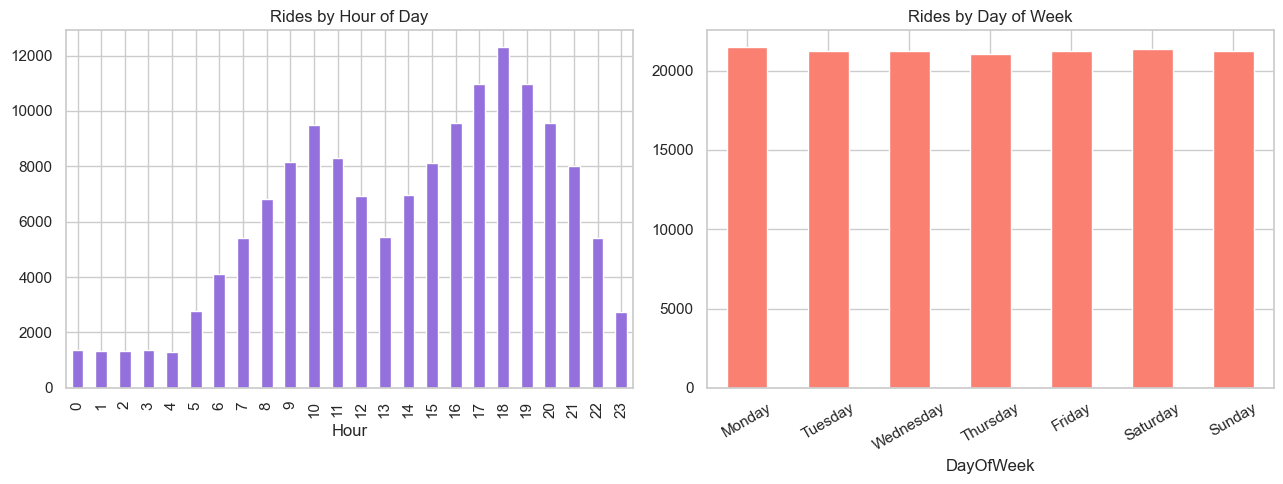

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Hourly
df['Hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='mediumpurple', edgecolor='white')
axes[0].set_title('Rides by Hour of Day')
axes[0].set_xlabel('Hour')

# Day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['DayOfWeek'].value_counts().reindex(day_order).plot(kind='bar', ax=axes[1],
    color='salmon', edgecolor='white')
axes[1].set_title('Rides by Day of Week')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'plot_05.png'), dpi=150, bbox_inches='tight')
print(f'Saved → {SAVE_DIR}/plot_05.png')
plt.show()

## Step 12 — Payment Method


Payment method mix has direct implications for cash-flow and fraud risk:
- **Cash-heavy mix** → higher reconciliation overhead and potential for fare disputes.
- **Digital-heavy mix** → easier auditing, but dependency on payment infrastructure.
- **Insight to watch for:** if one method dominates >70 %, consider whether the platform is actively promoting it or whether alternatives are unavailable/inconvenient.

Saved → C:\Users\Muhammad Waqas/plot_06.png


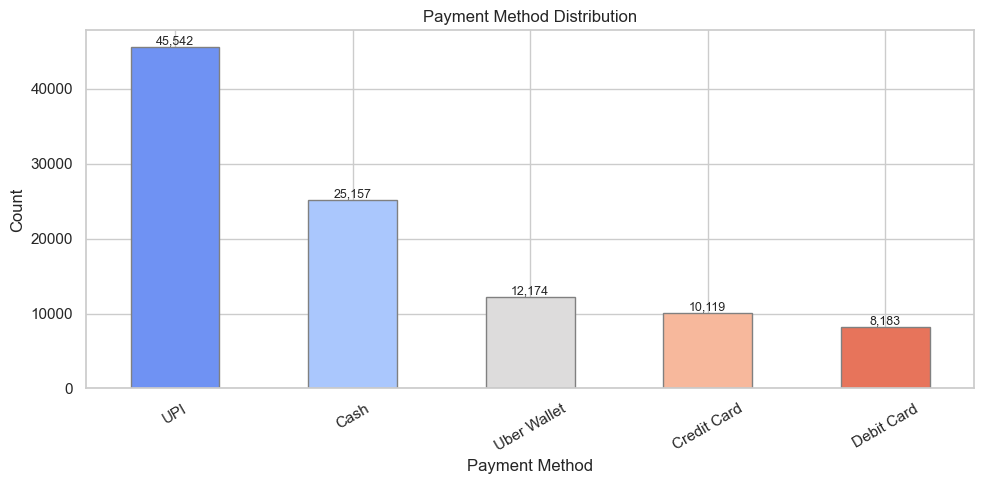

In [34]:
pay = df['Payment Method'].value_counts()
pay.plot(kind='bar', color=sns.color_palette('coolwarm', len(pay)), edgecolor='grey')
plt.title('Payment Method Distribution')
plt.xticks(rotation=30)
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'plot_06.png'), dpi=150, bbox_inches='tight')
print(f'Saved → {SAVE_DIR}/plot_06.png')
plt.show()

## Step 13 — Correlation Heatmap


Pearson correlations quantify **linear relationships** between numeric features:
- `Booking Value` vs. `Ride Distance` — expected positive correlation; weak correlation would be surprising.
- `Driver Ratings` vs. `Customer Rating` — moderate positive correlation is typical (satisfied customers tend to rate drivers well and vice versa).
- `Avg_VTAT_min` (vehicle time-at-trip) vs. `Booking Value` — longer trips cost more, so a positive correlation is expected.
- **Watch for:** near-zero correlations that challenge assumptions, or unexpectedly high correlations that suggest data leakage.

Saved → C:\Users\Muhammad Waqas/plot_07.png


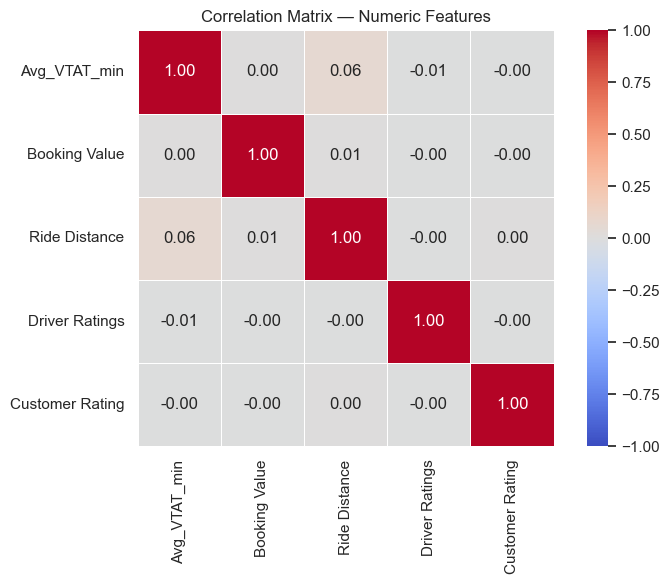

In [35]:
num_cols = ['Avg_VTAT_min','Booking Value','Ride Distance','Driver Ratings','Customer Rating']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'plot_07.png'), dpi=150, bbox_inches='tight')
print(f'Saved → {SAVE_DIR}/plot_07.png')
plt.show()

## Step 14 — Top Pickup & Drop Locations


Location analysis highlights **demand hotspots**:
- The top 10 pickup locations are the most critical supply-positioning targets.
- Comparing pickup vs. drop rankings reveals **directional imbalance** — if a location appears heavily in drops but rarely in pickups, drivers finishing there may struggle to find their next ride.
- **Business value:** this analysis directly informs zone-based surge pricing and driver relocation incentives.

Saved → C:\Users\Muhammad Waqas/plot_08.png


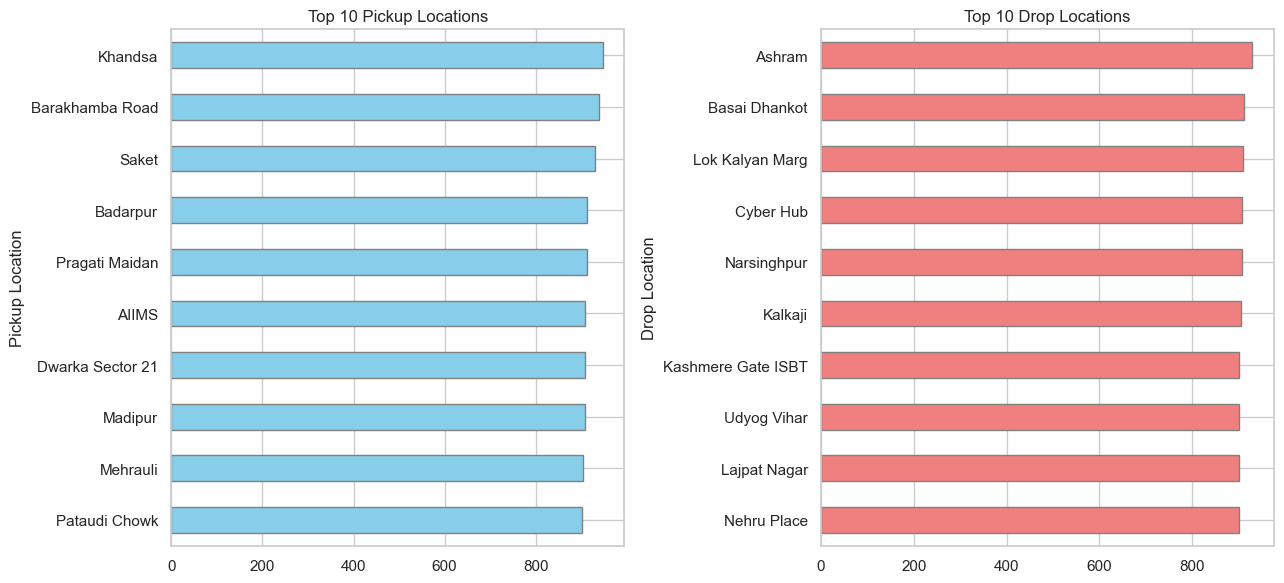

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

df['Pickup Location'].value_counts().head(10).sort_values().plot(
    kind='barh', ax=axes[0], color='skyblue', edgecolor='grey')
axes[0].set_title('Top 10 Pickup Locations')

df['Drop Location'].value_counts().head(10).sort_values().plot(
    kind='barh', ax=axes[1], color='lightcoral', edgecolor='grey')
axes[1].set_title('Top 10 Drop Locations')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'plot_08.png'), dpi=150, bbox_inches='tight')
print(f'Saved → {SAVE_DIR}/plot_08.png')
plt.show()

## Step 15 — Booking Value by Status (Box Plot)


A box plot by booking status answers: *"Are cancelled or incomplete rides typically high-value or low-value?"*
- **Median line** shows the central tendency per status group.
- **Box width (IQR)** shows spread — wide boxes mean high variability in that group.
- **Outlier dots** highlight anomalously large fares in any status.
- **Key insight:** if cancelled rides have a higher median value than completed ones, there may be a pricing-driven cancellation problem (customers cancel after seeing the fare).

Saved → C:\Users\Muhammad Waqas/plot_09.png


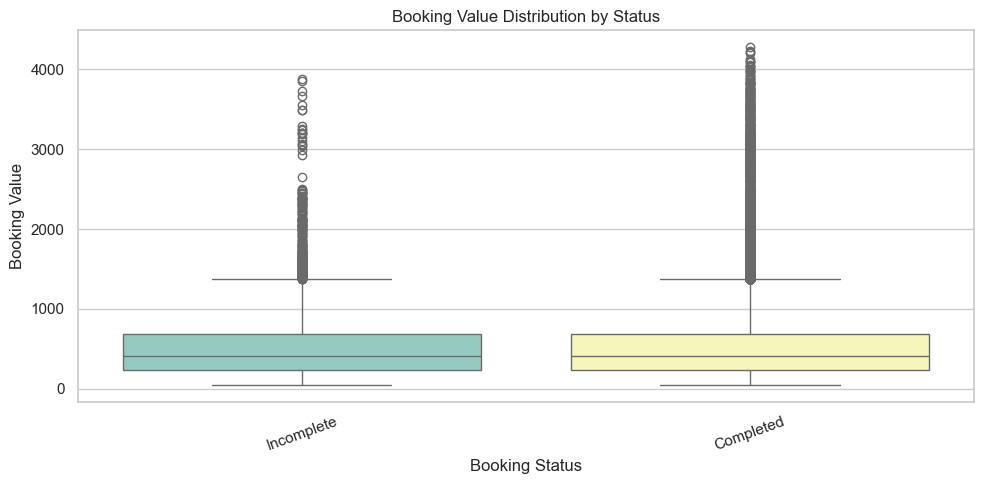

In [37]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df.dropna(subset=['Booking Value']),
            x='Booking Status', y='Booking Value',
            palette='Set3')
plt.title('Booking Value Distribution by Status')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'plot_09.png'), dpi=150, bbox_inches='tight')
print(f'Saved → {SAVE_DIR}/plot_09.png')
plt.show()

## Step 16 — Key Takeaways


A summary print consolidates the headline KPIs into a single shareable block:
- **Completion rate** is the primary health metric of the platform.
- **Cancellation rate** quantifies lost revenue and operational waste.
- **Avg Booking Value** and **Avg Ride Distance** set the baseline for revenue-per-ride modelling.
- **Avg Ratings** provide a NPS-adjacent quality signal.
- **Most popular vehicle & payment method** anchor any segmentation or targeting strategy.

In [38]:
completed_pct = (df['Booking Status'] == 'Completed').mean() * 100
cancelled_pct = df['Booking Status'].str.startswith('Cancel').mean() * 100

print('=== KEY METRICS ===')
print(f"Total rides          : {len(df):,}")
print(f"Completion rate      : {completed_pct:.1f}%")
print(f"Cancellation rate    : {cancelled_pct:.1f}%")
print(f"Avg Booking Value    : ₹{df['Booking Value'].mean():.0f}")
print(f"Avg Ride Distance    : {df['Ride Distance'].mean():.1f} km")
print(f"Avg Driver Rating    : {df['Driver Ratings'].mean():.2f}")
print(f"Avg Customer Rating  : {df['Customer Rating'].mean():.2f}")
print(f"Most popular vehicle : {df['Vehicle Type'].mode()[0]}")
print(f"Top payment method   : {df['Payment Method'].mode()[0]}")

=== KEY METRICS ===
Total rides          : 148,767
Completion rate      : 62.0%
Cancellation rate    : 25.0%
Avg Booking Value    : ₹508
Avg Ride Distance    : 24.6 km
Avg Driver Rating    : 4.23
Avg Customer Rating  : 4.40
Most popular vehicle : Auto
Top payment method   : UPI


## Step 17 — Export Cleaned Data

### 📌 EDA Note — Step 17: Export Cleaned Data
Saving the cleaned DataFrame closes the EDA loop:
- The CSV can be shared with stakeholders who don't use Python (e.g., Power BI / Tableau users).
- It serves as the input for downstream modelling (regression, clustering, churn prediction).
- **Confirm the final shape** matches expectations: rows should be ≤ raw rows (duplicates removed) and columns = raw columns − dropped columns.

In [39]:
df.to_csv('rideBookings_cleaned.csv', index=False)
print('Cleaned CSV saved as rideBookings_cleaned.csv ')
print(f'Final shape: {df.shape}')

Cleaned CSV saved as rideBookings_cleaned.csv 
Final shape: (148767, 18)
